# River Water Level Forecasting - Data Exploration, Preprocessing and Preliminary Analysis

**Practical Assignment: Regression Analysis**

**Dataset:** Islandwide Water Level and Rainfall Situation in Major Rivers of Sri Lanka (training data)

**Name:** Ekanayake D.B

**Index No:** 235514B

## Purpose of this notebook

The assignment recommends beginning *data exploration, preprocessing and preliminary analysis* of the
training dataset before the practical session. This notebook covers exactly those three stages and
prepares a clean dataset and a set of findings that will feed directly into the full regression analysis
(model development, diagnostics and evaluation) carried out during the session.

## Objective of the wider study

Develop a regression model that predicts the river water level **12 hours ahead**
(`Water_Level_Xt`) from the current water level and the rainfall received over the previous 24 hours.

## Variables

| Variable | Description | Role |
|---|---|---|
| `Gauging_station` | Identifier of the gauging station | Identifier (not a predictor) |
| `Water_Level_Xt_1` | River water level (mm) at time t | Predictor |
| `24HrRF_Xt_1` | Total rainfall (mm) in the previous 24 hours at time t | Predictor |
| `Water_Level_Xt` | River water level (mm) at time t + 12 hours | Target |

## Contents

1. Setup and data loading
2. Data exploration
3. Preprocessing
4. Preliminary analysis
5. Summary of findings and next steps


## 1. Setup and data loading

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# The CSV is expected in the same folder as this notebook
df = pd.read_csv("training_data.csv")
df.head()

,Gauging_station,Water_Level_Xt_1,24HrRF_Xt_1,Water_Level_Xt
0,1,2.900,NaN,1.500
1,2,5.000,23.200,3.710
2,3,12.680,44.300,11.050
3,4,1.600,51.700,1.810
4,5,1.280,81.200,0.870


The data is read into a pandas DataFrame. Each row corresponds to one gauging station, with two
predictor columns (current water level and 24 hour rainfall) and the target column (water level 12 hours
later).

## 2. Data exploration

### 2.1 Shape, structure and data types

In [3]:
print("Rows, columns:", df.shape)
print()
df.info()

Rows, columns: (78, 4)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gauging_station   78 non-null     int64  
 1   Water_Level_Xt_1  78 non-null     float64
 2   24HrRF_Xt_1       76 non-null     float64
 3   Water_Level_Xt    72 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 2.6 KB


The dataset has 78 rows and 4 columns. `Gauging_station` is an integer identifier; the remaining
three columns are floating point numeric variables, which is appropriate for water level and rainfall
measurements. No column needs a type conversion.

### 2.2 Summary statistics

In [4]:
df.describe()

,Gauging_station,Water_Level_Xt_1,24HrRF_Xt_1,Water_Level_Xt
count,78.000,78.000,76.000,72.000
mean,39.500,2.133,21.441,2.145
std,22.661,2.593,21.425,2.377
min,1.000,-3.270,0.000,-0.130
25%,20.250,0.630,3.325,0.617
50%,39.500,1.325,14.950,1.355
75%,58.750,2.953,32.300,2.652
max,78.000,12.680,81.200,11.730


Key points from the summary:

- `Water_Level_Xt_1` and the target `Water_Level_Xt` have very similar centre and spread
  (mean near 2.1, comparable quartiles). This is expected, because the target is essentially the same
  river level recorded 12 hours later.
- `24HrRF_Xt_1` ranges from 0 mm (dry stations) up to roughly 81 mm (heavy rain), with a median well
  below the mean, which already hints at a right skewed distribution.
- The minimum water levels are negative (about -3.3). Water levels are recorded relative to a
  station specific reference datum, so negative readings are physically valid and indicate a level below
  that reference. They are not data errors.
- The `count` row shows fewer than 78 values for `24HrRF_Xt_1` and `Water_Level_Xt`, which signals
  missing values examined next.

### 2.3 Missing values

In [5]:
missing = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)
miss_table = pd.DataFrame({"missing_count": missing, "missing_percent": missing_pct})
print(miss_table)

print("\nStations missing rainfall (24HrRF_Xt_1):",
      df.loc[df["24HrRF_Xt_1"].isna(), "Gauging_station"].tolist())
print("Stations missing target (Water_Level_Xt):",
      df.loc[df["Water_Level_Xt"].isna(), "Gauging_station"].tolist())
print("\nFully complete rows:", df.dropna().shape[0], "of", len(df))

                  missing_count  missing_percent
Gauging_station               0            0.000
Water_Level_Xt_1              0            0.000
24HrRF_Xt_1                   2            2.560
Water_Level_Xt                6            7.690

Stations missing rainfall (24HrRF_Xt_1): [1, 40]
Stations missing target (Water_Level_Xt): [28, 34, 35, 67, 73, 74]

Fully complete rows: 70 of 78


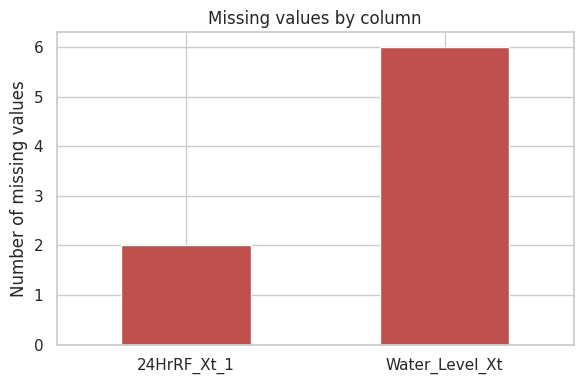

In [6]:
plt.figure(figsize=(6, 4))
missing[missing > 0].plot(kind="bar", color="#c0504d")
plt.title("Missing values by column")
plt.ylabel("Number of missing values")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

There are two distinct missing data situations:

- `24HrRF_Xt_1` is missing for 2 stations (1 and 40). These rows still have a valid current water level
  and a valid target, so they can be recovered by imputation.
- `Water_Level_Xt` (the target) is missing for 6 stations (28, 34, 35, 67, 73, 74). A supervised
  regression model cannot be trained on rows that have no target value, and imputing a target would
  fabricate the quantity we are trying to predict. These rows are therefore not usable for training.

The two groups do not overlap, so 78 - 6 = 72 rows remain usable once the missing target rows are removed.

### 2.4 Distributions of the numeric variables

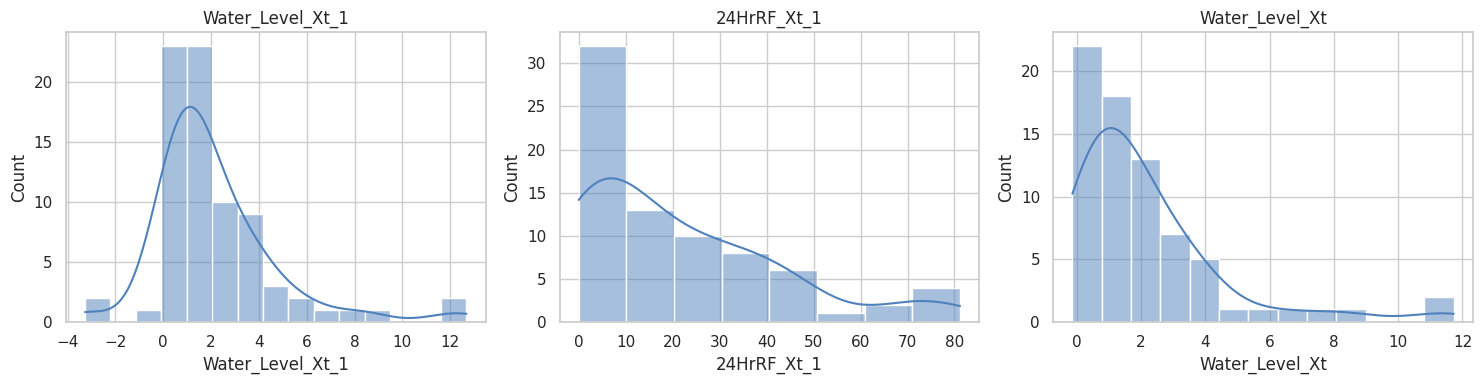

Skewness:
Water_Level_Xt_1   1.808
24HrRF_Xt_1        1.133
Water_Level_Xt     2.256
dtype: float64


In [7]:
num_cols = ["Water_Level_Xt_1", "24HrRF_Xt_1", "Water_Level_Xt"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="#4f81bd")
    ax.set_title(col)
plt.tight_layout()
plt.show()

print("Skewness:")
print(df[num_cols].skew().round(3))

All three variables are clearly right skewed (positive skewness). Most stations sit at low water
levels and low rainfall, while a small number of stations show large values. This is typical of
hydrological data, where a few large rivers or heavy rainfall events dominate the upper tail. The skew is
worth noting now, because it can affect the spread of regression residuals and may motivate a
transformation if the model diagnostics later show problems.

### 2.5 Outlier detection

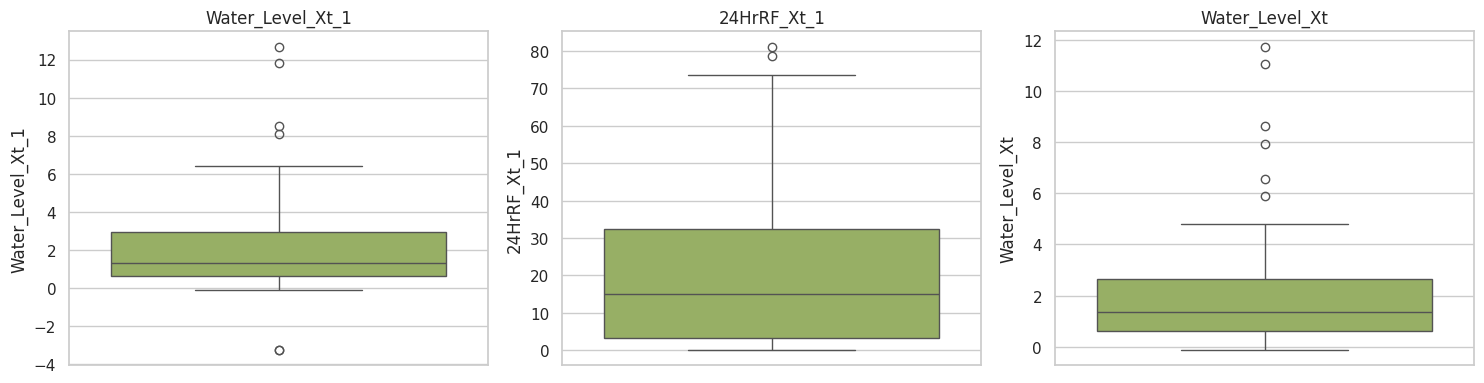

IQR based outlier check:
  Water_Level_Xt_1: fence [-2.85, 6.44], stations = [3, 9, 28, 42, 48, 67]
  24HrRF_Xt_1: fence [-40.14, 75.76], stations = [5, 6]
  Water_Level_Xt: fence [-2.44, 5.71], stations = [3, 9, 12, 42, 48, 51]

Stations with negative current water level: [23, 27, 28, 62, 66, 67]


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color="#9bbb59")
    ax.set_title(col)
plt.tight_layout()
plt.show()

# IQR based flags
print("IQR based outlier check:")
for col in num_cols:
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    flagged = df.loc[(df[col] < lo) | (df[col] > hi), "Gauging_station"].tolist()
    print(f"  {col}: fence [{lo:.2f}, {hi:.2f}], stations = {flagged}")

print("\nStations with negative current water level:",
      df.loc[df["Water_Level_Xt_1"] < 0, "Gauging_station"].tolist())

The boxplots and the IQR rule flag values at the upper end of the water level columns (for example
stations 3, 9, 42 and 48). These correspond to genuinely large rivers carrying high flow, so they are
real measurements rather than errors and should be kept. Removing them would discard exactly the
high level behaviour the model needs to learn.

The negative water levels (stations 23, 27, 28, 62, 66, 67) are valid readings below the local reference
datum, as discussed earlier. Two of these, stations 28 and 67, also appear as low end outliers and happen
to be among the rows whose target is missing, so they are removed during preprocessing for a separate
reason. No outlier is treated as an error at this stage.

### 2.6 Correlation analysis

                  Water_Level_Xt_1  24HrRF_Xt_1  Water_Level_Xt
Water_Level_Xt_1             1.000        0.363           0.990
24HrRF_Xt_1                  0.363        1.000           0.316
Water_Level_Xt               0.990        0.316           1.000


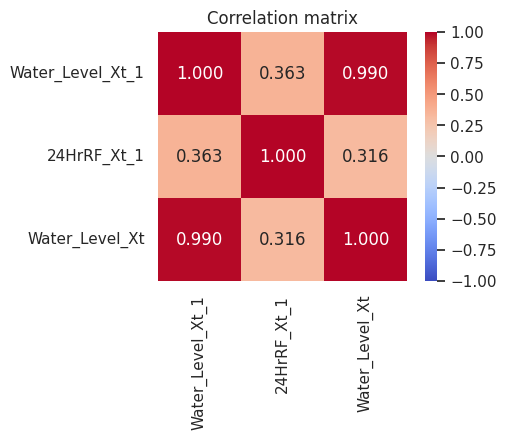

In [9]:
corr = df[num_cols].corr()
print(corr.round(4))

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

The correlation structure is the most informative result of the exploration:

- `Water_Level_Xt_1` and the target `Water_Level_Xt` are very strongly correlated (about 0.99). The
  current water level is an excellent linear predictor of the level 12 hours ahead.
- `24HrRF_Xt_1` has a much weaker correlation with the target (about 0.32). Rainfall carries some signal
  but far less than the current level.
- The two predictors are only weakly correlated with each other (about 0.36), so multicollinearity is
  unlikely to be a problem when both are used together.

### 2.7 Predictor versus target relationships

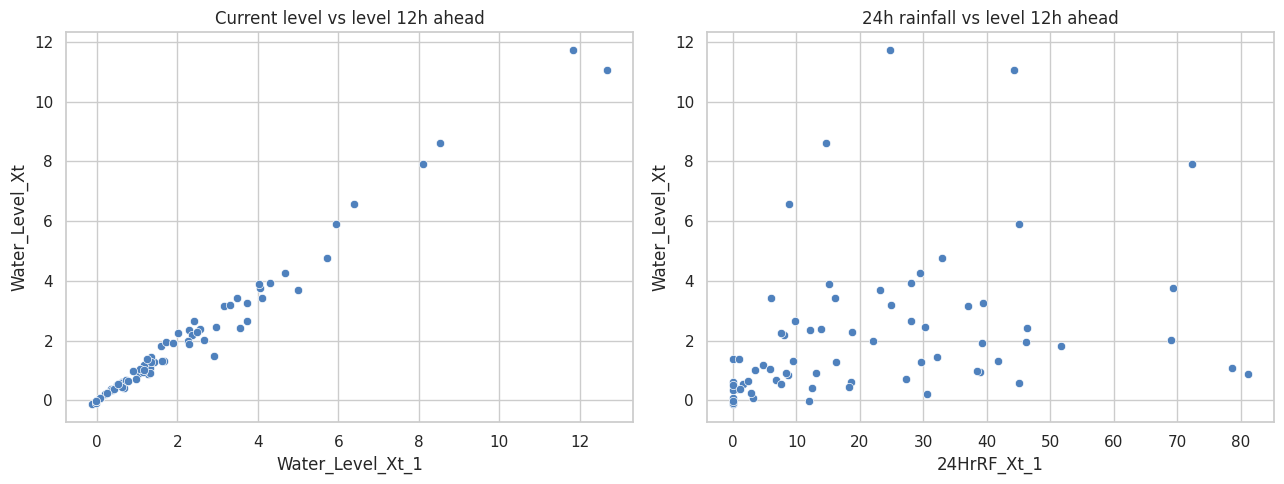

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=df, x="Water_Level_Xt_1", y="Water_Level_Xt", ax=axes[0], color="#4f81bd")
axes[0].set_title("Current level vs level 12h ahead")
sns.scatterplot(data=df, x="24HrRF_Xt_1", y="Water_Level_Xt", ax=axes[1], color="#4f81bd")
axes[1].set_title("24h rainfall vs level 12h ahead")
plt.tight_layout()
plt.show()

The left scatter shows a tight, near straight line relationship between the current level and the
level 12 hours ahead, consistent with the 0.99 correlation. The right scatter shows only a loose upward
cloud for rainfall, consistent with its weak correlation. This visual evidence supports a linear
regression approach with the current water level as the dominant predictor.

## 3. Preprocessing

Based on the exploration, the cleaning steps are kept minimal and justified:
1. Set the identifier aside so it is not used as a predictor.
2. Remove rows with a missing target (cannot be used to train).
3. Impute the small number of missing rainfall values.
4. Keep valid outliers and negative readings.

### 3.1 Separate the identifier from the modelling variables

In [11]:
station_id = df["Gauging_station"].copy()       # kept for reference only
data = df.drop(columns=["Gauging_station"]).copy()
data.head()

,Water_Level_Xt_1,24HrRF_Xt_1,Water_Level_Xt
0,2.900,NaN,1.500
1,5.000,23.200,3.710
2,12.680,44.300,11.050
3,1.600,51.700,1.810
4,1.280,81.200,0.870


`Gauging_station` is a label, not a measurement. Using an arbitrary station number as a numeric
predictor would inject meaningless ordering into the model, so it is removed from the modelling frame and
retained separately for traceability.

### 3.2 Remove rows with a missing target

In [12]:
before = len(data)
data = data.dropna(subset=["Water_Level_Xt"]).copy()
print(f"Removed {before - len(data)} rows with missing target. Remaining rows: {len(data)}")

Removed 6 rows with missing target. Remaining rows: 72


The 6 rows without a `Water_Level_Xt` value are removed because supervised regression requires a
known target for every training row. These stations can still receive predictions later if they appear in
the test set, but they cannot contribute to fitting the model.

### 3.3 Impute the missing rainfall values

In [13]:
rain_median = data["24HrRF_Xt_1"].median()
print("Rainfall median used for imputation:", round(rain_median, 3))

data["24HrRF_Xt_1"] = data["24HrRF_Xt_1"].fillna(rain_median)
print("Remaining missing values in the modelling frame:", int(data.isna().sum().sum()))

Rainfall median used for imputation: 15.65
Remaining missing values in the modelling frame: 0


Only 2 rainfall values are missing. The median is used rather than the mean because rainfall is
right skewed, which makes the median a more representative central value and avoids pulling the imputed
figure toward the heavy rain tail. With so few imputed points the effect on the analysis is negligible,
while keeping these rows preserves their valid current level and target information.

### 3.4 Treatment of outliers and negative values

No outlier or negative value is altered. The high water level points are real high flow stations,
and the negative levels are valid readings relative to a local datum. Both represent legitimate behaviour
the model should capture, so they are retained. This decision can be revisited during model diagnostics if
specific points turn out to be high influence.

### 3.5 Clean modelling dataset

In [14]:
print("Final modelling dataset shape:", data.shape)
print("Missing values:", int(data.isna().sum().sum()))
data.describe()

Final modelling dataset shape: (72, 3)
Missing values: 0


,Water_Level_Xt_1,24HrRF_Xt_1,Water_Level_Xt
count,72.000,72.000,72.000
mean,2.345,21.771,2.145
std,2.518,20.543,2.377
min,-0.120,0.000,-0.130
25%,0.660,5.950,0.617
50%,1.375,15.650,1.355
75%,3.202,32.300,2.652
max,12.680,81.200,11.730


## 4. Preliminary analysis

A short baseline regression is fitted to confirm the predictive structure seen in the exploration. This
is a preliminary check, not the final model. Full model development, diagnostics and evaluation are done
during the session.

### 4.1 Correlation with the target on the clean data

In [15]:
data.corr()["Water_Level_Xt"].sort_values(ascending=False).round(4)

,Water_Level_Xt
Water_Level_Xt,1.000
Water_Level_Xt_1,0.990
24HrRF_Xt_1,0.317


On the cleaned data the ranking is unchanged: the current water level dominates, rainfall is a weak
secondary predictor.

### 4.2 Baseline simple regression (current level only)

In [16]:
y = data["Water_Level_Xt"]
X_simple = sm.add_constant(data[["Water_Level_Xt_1"]])
simple_model = sm.OLS(y, X_simple).fit()
print(simple_model.summary())

                            OLS Regression Results                            
Dep. Variable:         Water_Level_Xt   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     3410.
Date:                Thu, 25 Jun 2026   Prob (F-statistic):           4.02e-61
Time:                        12:58:58   Log-Likelihood:                -23.377
No. Observations:                  72   AIC:                             50.75
Df Residuals:                      70   BIC:                             55.31
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.0467      0.055  

Using only the current water level already explains almost all of the variation in the level 12
hours ahead (very high R squared). The slope is close to 1 and highly significant, which matches the
physical intuition that the river level changes only gradually over a 12 hour window.

### 4.3 Baseline multivariate regression (both predictors)

In [17]:
X_multi = sm.add_constant(data[["Water_Level_Xt_1", "24HrRF_Xt_1"]])
multi_model = sm.OLS(y, X_multi).fit()
print(multi_model.summary())

                            OLS Regression Results                            
Dep. Variable:         Water_Level_Xt   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     1725.
Date:                Thu, 25 Jun 2026   Prob (F-statistic):           1.23e-59
Time:                        12:58:58   Log-Likelihood:                -22.463
No. Observations:                  72   AIC:                             50.93
Df Residuals:                      69   BIC:                             57.76
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.0046      0.063  

Adding rainfall produces only a marginal change in fit, and its coefficient is not statistically
significant once the current level is included. This is consistent with the weak rainfall to target
correlation and the low correlation between the two predictors. The current water level carries almost all
of the predictive information.

These are preliminary fits. Whether rainfall should stay in the final model, and whether a transformation
is needed for the right skewed variables, will be decided during the session using formal diagnostics
(residual plots, normal Q-Q plot, Durbin-Watson, VIF) and proper evaluation.

## 5. Summary of findings and next steps

### What the data looks like
- 78 rows, one per gauging station, with two numeric predictors and one numeric target.
- All measurement columns are numeric and correctly typed; `Gauging_station` is an identifier only.
- All three measurement variables are right skewed; water levels and rainfall both have a long upper tail.

### Data quality
- Missing data: rainfall missing for 2 stations (1, 40); target missing for 6 stations
  (28, 34, 35, 67, 73, 74).
- Negative water levels are valid readings relative to a station reference datum, not errors.
- Upper tail water level values are real high flow stations and are kept.

### Preprocessing applied
- Removed `Gauging_station` from the modelling variables and kept it separately.
- Dropped the 6 rows with a missing target (cannot be used for supervised training).
- Imputed the 2 missing rainfall values with the median (robust to skew).
- Retained valid outliers and negative readings.
- Result: a clean modelling dataset of 72 rows with no missing values.

### Preliminary signal
- The current water level is an extremely strong, near linear predictor of the level 12 hours ahead
  (correlation about 0.99).
- Rainfall over the previous 24 hours is only weakly related to the target and is not significant once the
  current level is in the model.
- The two predictors are only weakly correlated with each other, so multicollinearity is not a concern.

### Carried into the session
- Build and compare the univariate model (current level) and the multivariate model (current level plus
  rainfall).
- Run full diagnostics: residuals versus fitted, normal Q-Q plot, Durbin-Watson, and VIF.
- Consider a transformation if the skew shows up in the residuals.
- Evaluate the chosen model and then generate predictions for the test dataset in Task 2.
